In [1]:
import numpy as np
import matplotlib.pyplot as plt

csv_path = "mtfuji_data.csv"

fuji = np.loadtxt(
    csv_path,
    delimiter=",",
    skiprows=1
)

print("Shape:", fuji.shape)

Shape: (300, 5)


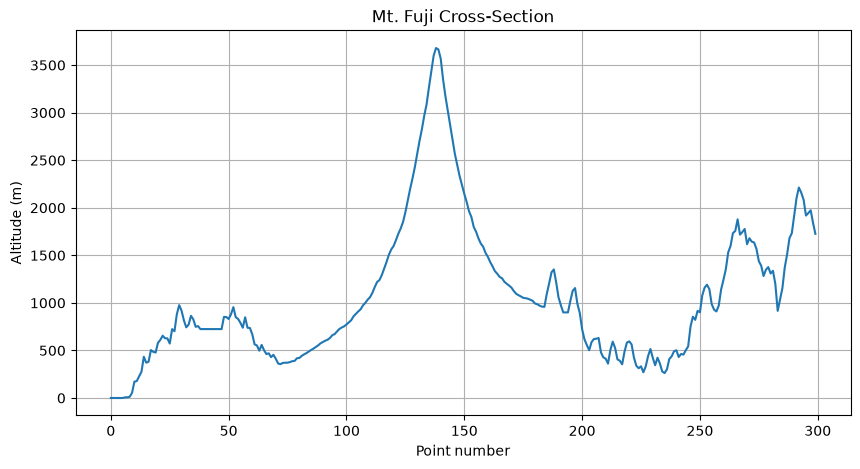

In [2]:
point = fuji[:, 0]
altitude = fuji[:, 3]

plt.figure(figsize=(10, 5))
plt.plot(point, altitude)

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Mt. Fuji Cross-Section")
plt.grid()
plt.show()

In [3]:
# Problem 2: Calculate the gradient at a given point

def calculate_gradient(fuji, current_point):
    """
    Calculate the approximate gradient between the current point
    and the previous point.
    
    For point 0, there is no previous point, so return None.
    """
    
    if current_point == 0:
        return None
    
    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]
    
    current_x = fuji[current_point, 0]
    previous_x = fuji[current_point - 1, 0]
    
    gradient = (current_altitude - previous_altitude) / (current_x - previous_x)
    
    return gradient

In [4]:
print("Gradient at point 0:", calculate_gradient(fuji, 0))
print("Gradient at point 1:", calculate_gradient(fuji, 1))
print("Gradient at point 100:", calculate_gradient(fuji, 100))

Gradient at point 0: None
Gradient at point 1: 0.0
Gradient at point 100: 18.90000000000009


In [6]:
# Problem 2: Calculate the gradient

def calculate_gradient(fuji, current_point):
    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    current_x = fuji[current_point, 0]
    previous_x = fuji[current_point - 1, 0]

    gradient = (current_altitude - previous_altitude) / (current_x - previous_x)

    return gradient

In [7]:
print("Gradient at point 0:", calculate_gradient(fuji, 0))
print("Gradient at point 1:", calculate_gradient(fuji, 1))
print("Gradient at point 100:", calculate_gradient(fuji, 100))

Gradient at point 0: None
Gradient at point 1: 0.0
Gradient at point 100: 18.90000000000009


In [8]:
# Problem 3: Calculate the destination point

# First, define the gradient function from Problem 2
def calculate_gradient(fuji, current_point):
    """
    Calculate the approximate gradient between
    the current point and the previous point.
    """

    # Point 0 has no previous point
    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    current_x = fuji[current_point, 0]
    previous_x = fuji[current_point - 1, 0]

    gradient = (
        (current_altitude - previous_altitude)
        / (current_x - previous_x)
    )

    return gradient


# Define the destination function
def calculate_destination(fuji, current_point, alpha=0.2):
    """
    Calculate the next point using the gradient.

    destination = current_point - alpha * gradient
    """

    # Calculate the gradient
    gradient = calculate_gradient(fuji, current_point)

    # Point 0 has no previous point
    if gradient is None:
        return current_point

    # Calculate destination
    destination = current_point - alpha * gradient

    # Round to the nearest integer
    destination = int(round(destination))

    # Keep destination within valid range
    if destination < 0:
        destination = 0
    elif destination >= len(fuji):
        destination = len(fuji) - 1

    return destination


# Test the function
print("Destination from point 0:",
      calculate_destination(fuji, 0))

print("Destination from point 100:",
      calculate_destination(fuji, 100))

print("Destination from point 200:",
      calculate_destination(fuji, 200))

Destination from point 0: 0
Destination from point 100: 96
Destination from point 200: 234


In [9]:
# Problem 4: Descend the mountain

# Problem 2: Calculate the gradient
def calculate_gradient(fuji, current_point):
    """
    Calculate the approximate gradient between
    the current point and the previous point.
    """

    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    current_x = fuji[current_point, 0]
    previous_x = fuji[current_point - 1, 0]

    gradient = (
        (current_altitude - previous_altitude)
        / (current_x - previous_x)
    )

    return gradient


# Problem 3: Calculate the destination
def calculate_destination(fuji, current_point, alpha=0.2):
    """
    Calculate the next point using the gradient.
    """

    gradient = calculate_gradient(fuji, current_point)

    if gradient is None:
        return current_point

    destination = current_point - alpha * gradient

    # Round to an integer
    destination = int(round(destination))

    # Keep the destination within the valid range
    if destination < 0:
        destination = 0
    elif destination >= len(fuji):
        destination = len(fuji) - 1

    return destination


# Problem 4: Descend the mountain
def descend_mountain(fuji, start_point=136, alpha=0.2):
    """
    Descend the mountain starting from start_point.

    Returns:
        List of points visited during the descent.
    """

    current_point = start_point

    # Store the starting point
    path = [current_point]

    while True:

        # Calculate the next point
        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop if the point does not change
        if next_point == current_point:
            break

        # Add the new point to the path
        path.append(next_point)

        # Update the current point
        current_point = next_point

    return path


# Run the simulation
path = descend_mountain(fuji)

print("Points visited:")
print(path)

print("Number of steps:", len(path))
print("Final point:", path[-1])
print("Final altitude:", fuji[path[-1], 3])

Points visited:
[136, 102, 98, 95, 93, 89, 85, 82, 79, 73, 70, 78, 77, 75]
Number of steps: 14
Final point: 75
Final altitude: 371.19


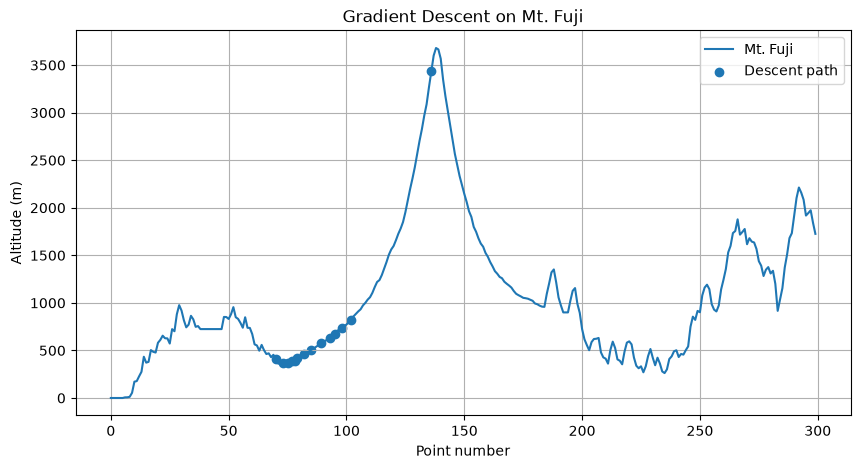

In [10]:
# Problem 5: Visualization of the descent process

import matplotlib.pyplot as plt

# Run the descent from point 136
path = descend_mountain(fuji, start_point=136, alpha=0.2)

# Get the altitudes of the visited points
path_altitudes = fuji[path, 3]

# Plot the cross-section
plt.figure(figsize=(10, 5))

plt.plot(fuji[:, 0], fuji[:, 3], label="Mt. Fuji")
plt.scatter(path, path_altitudes, label="Descent path")

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent on Mt. Fuji")
plt.legend()
plt.grid()

plt.show()

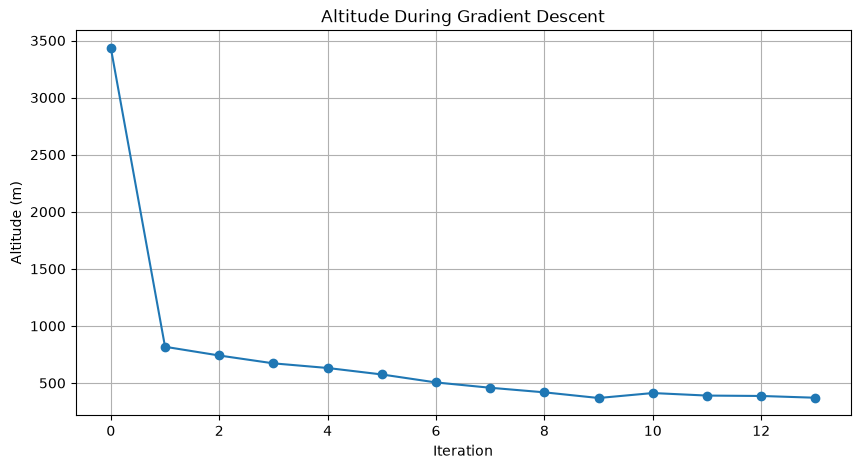

In [11]:
# Altitude at each step

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(path)),
    path_altitudes,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Altitude (m)")
plt.title("Altitude During Gradient Descent")
plt.grid()

plt.show()

In [12]:
def descend_mountain(fuji, start_point=136, alpha=0.2):
    """
    Descend Mt. Fuji from a specified starting point.
    """

    # Check that the starting point is valid
    if start_point < 0 or start_point >= len(fuji):
        raise ValueError(
            f"Invalid start_point: {start_point}. "
            f"Valid range is 0 to {len(fuji) - 1}."
        )

    current_point = start_point
    path = [current_point]

    while True:

        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop if the point does not change
        if next_point == current_point:
            break

        path.append(next_point)
        current_point = next_point

    return path

In [ ]:
# Problem 6: Change the starting point

def descend_mountain(fuji, start_point=136, alpha=0.2):

    # Check the starting point
    if start_point < 0 or start_point >= len(fuji):
        raise ValueError(
            f"Invalid start point: {start_point}. "
            f"Choose a value between 0 and {len(fuji) - 1}."
        )

    current_point = start_point
    path = [current_point]

    while True:

        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop when the point does not change
        if next_point == current_point:
            break

        path.append(next_point)
        current_point = next_point

    return path


# Test different starting points

starting_points = [100, 120, 136, 142, 160, 180]

for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    final_point = path[-1]
    final_altitude = fuji[final_point, 3]

    print(
        f"Starting point: {start_point} | "
        f"Final point: {final_point} | "
        f"Final altitude: {final_altitude:.2f} m | "
        f"Steps: {len(path)}"
    )

In [ ]:
# ==========================================
# PROBLEM 6 - Change the starting point
# ==========================================

def calculate_gradient(fuji, current_point):
    """Calculate the gradient between the current and previous point."""

    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    current_point_number = fuji[current_point, 0]
    previous_point_number = fuji[current_point - 1, 0]

    gradient = (
        (current_altitude - previous_altitude)
        / (current_point_number - previous_point_number)
    )

    return gradient


def calculate_destination(fuji, current_point, alpha=0.2):
    """Calculate the next point."""

    gradient = calculate_gradient(fuji, current_point)

    if gradient is None:
        return current_point

    destination = current_point - alpha * gradient

    destination = int(round(destination))

    # Keep the point inside the dataset
    destination = max(0, min(destination, len(fuji) - 1))

    return destination


def descend_mountain(fuji, start_point=136, alpha=0.2):
    """Descend Mt. Fuji from a given starting point."""

    # Check the starting point
    if start_point < 0 or start_point >= len(fuji):
        raise ValueError(
            f"start_point must be between 0 and {len(fuji) - 1}"
        )

    current_point = start_point

    # Store every point visited
    path = [current_point]

    while True:

        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop if the point does not change
        if next_point == current_point:
            break

        path.append(next_point)

        current_point = next_point

    return path


# ==========================================
# TEST PROBLEM 6
# ==========================================

starting_points = [100, 120, 136, 142, 160, 180]

for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    final_point = path[-1]
    final_altitude = fuji[final_point, 3]

    print(
        "Start:", start_point,
        "| Final point:", final_point,
        "| Final altitude:", round(final_altitude, 2),
        "| Number of steps:", len(path)
    )

In [ ]:
print("TEST")

In [1]:
print("TEST")

TEST


In [2]:
print("fuji shape:", fuji.shape)

NameError: name 'fuji' is not defined

In [3]:
import numpy as np
import matplotlib.pyplot as plt

csv_path = "mtfuji_data.csv"

fuji = np.loadtxt(
    csv_path,
    delimiter=",",
    skiprows=1
)

print("Data loaded successfully!")
print("Shape:", fuji.shape)

Data loaded successfully!
Shape: (300, 5)


In [4]:
print("Point 136:")
print(fuji[136])

Point 136:
[1.36000000e+02 3.53625550e+01 1.38739261e+02 3.43459000e+03
 4.38210000e+04]


In [ ]:
# ==========================================
# PROBLEM 6 - Change the starting point
# ==========================================

def calculate_gradient(fuji, current_point):
    """Calculate the gradient between the current and previous point."""

    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    current_point_number = fuji[current_point, 0]
    previous_point_number = fuji[current_point - 1, 0]

    gradient = (
        (current_altitude - previous_altitude)
        / (current_point_number - previous_point_number)
    )

    return gradient


def calculate_destination(fuji, current_point, alpha=0.2):
    """Calculate the next point."""

    gradient = calculate_gradient(fuji, current_point)

    if gradient is None:
        return current_point

    destination = current_point - alpha * gradient

    destination = int(round(destination))

    # Keep the point inside the dataset
    destination = max(0, min(destination, len(fuji) - 1))

    return destination


def descend_mountain(fuji, start_point=136, alpha=0.2):
    """Descend Mt. Fuji from a given starting point."""

    # Check the starting point
    if start_point < 0 or start_point >= len(fuji):
        raise ValueError(
            f"start_point must be between 0 and {len(fuji) - 1}"
        )

    current_point = start_point

    # Store every point visited
    path = [current_point]

    while True:

        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop if the point does not change
        if next_point == current_point:
            break

        path.append(next_point)

        current_point = next_point

    return path


# ==========================================
# TEST PROBLEM 6
# ==========================================

starting_points = [100, 120, 136, 142, 160, 180]

for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    final_point = path[-1]
    final_altitude = fuji[final_point, 3]

    print(
        "Start:", start_point,
        "| Final point:", final_point,
        "| Final altitude:", round(final_altitude, 2),
        "| Number of steps:", len(path)
    )

Start: 100 | Final point: 75 | Final altitude: 371.19 | Number of steps: 8
Start: 120 | Final point: 75 | Final altitude: 371.19 | Number of steps: 15
Start: 136 | Final point: 75 | Final altitude: 371.19 | Number of steps: 14


In [ ]:
# ==========================================
# PROBLEM 7 - Visualization
# ==========================================

import matplotlib.pyplot as plt

starting_points = [100, 120, 136, 142, 160, 180]

plt.figure(figsize=(12, 6))

# Mt. Fuji
plt.plot(
    fuji[:, 0],
    fuji[:, 3],
    label="Mt. Fuji"
)

# Draw each descent
for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    altitude = fuji[path, 3]

    plt.plot(
        path,
        altitude,
        marker="o",
        label=f"Start {start_point}"
    )

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent from Different Starting Points")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Problem 7: Visualization of the descent
# for different starting points

import matplotlib.pyplot as plt

starting_points = [100, 120, 136, 142, 160, 180]

plt.figure(figsize=(12, 6))

# Plot Mt. Fuji
plt.plot(
    fuji[:, 0],
    fuji[:, 3],
    label="Mt. Fuji"
)

# Plot the descent for each starting point
for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    path_altitude = fuji[path, 3]

    plt.scatter(
        path,
        path_altitude,
        label=f"Start {start_point}"
    )

# Labels and title
plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent from Different Starting Points")

plt.legend()
plt.grid()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fuji[:, 0], fuji[:, 3])
plt.xlabel("Point")
plt.ylabel("Altitude")
plt.title("Mt. Fuji")
plt.show()

In [ ]:
path = descend_mountain(fuji, start_point=136, alpha=0.2)

print("Path:", path)
print("Number of points:", len(path))

In [ ]:
# Problem 7: Gradient descent from different starting points

import matplotlib.pyplot as plt

starting_points = [100, 120, 136, 142, 160, 180]

# Create the figure
plt.figure(figsize=(10, 6))

# Plot Mt. Fuji
plt.plot(fuji[:, 0], fuji[:, 3])

# Calculate and plot each descent
for start_point in starting_points:
    path = descend_mountain(fuji, start_point, alpha=0.2)
    
    # Get altitude for each visited point
    altitude = fuji[path, 3]
    
    plt.plot(path, altitude, marker="o")

# Add labels
plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent from Different Starting Points")

plt.grid()
plt.show()

In [ ]:
print("Starting Problem 7")

starting_points = [100, 120, 136, 142, 160, 180]

for start_point in starting_points:
    path = descend_mountain(fuji, start_point, alpha=0.2)
    print(start_point, "->", path)
    
print("Problem 7 finished")

In [ ]:
print("HELLO")

In [1]:
print("HELLO")

HELLO


In [2]:
import numpy as np

fuji = np.loadtxt(
    "mtfuji_data.csv",
    delimiter=",",
    skiprows=1
)

print(fuji.shape)

(300, 5)


NameError: name 'descend_mountain' is not defined

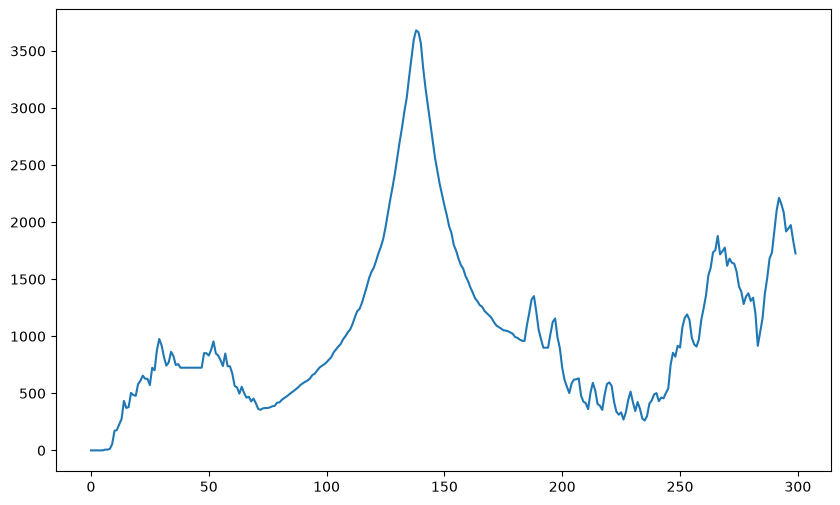

In [3]:
# Problem 7: Visualization of gradient descent
# from different starting points

import matplotlib.pyplot as plt

starting_points = [100, 120, 136, 142, 160, 180]

plt.figure(figsize=(10, 6))

# Draw Mt. Fuji
plt.plot(
    fuji[:, 0],
    fuji[:, 3],
    label="Mt. Fuji"
)

# Draw the descent from each starting point
for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    altitude = fuji[path, 3]

    plt.scatter(
        path,
        altitude,
        label=f"Start {start_point}"
    )

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent from Different Starting Points")

plt.legend()
plt.grid()

plt.show()

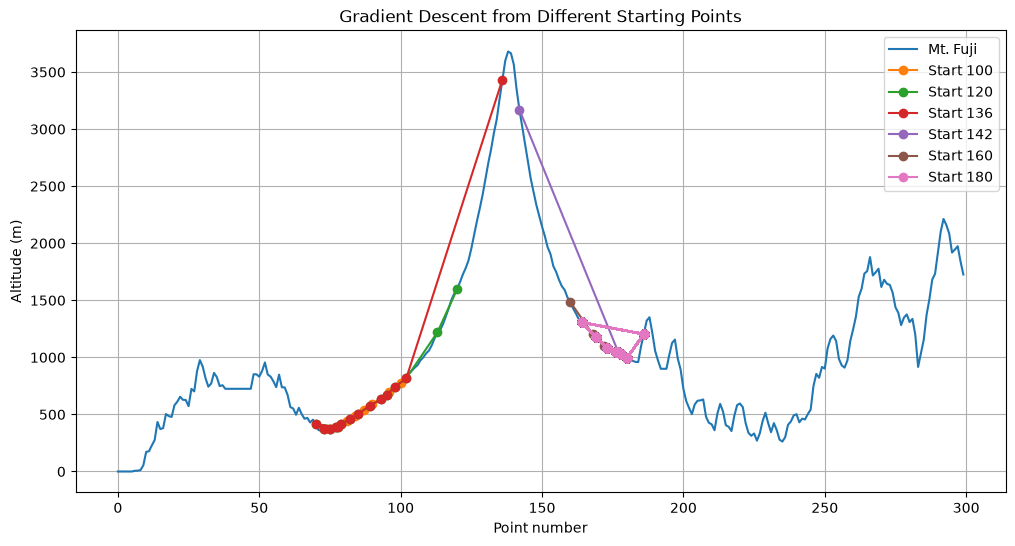

Results:
Start 100 -> Final point 75, Final altitude 371.19 m, Steps 8
Start 120 -> Final point 75, Final altitude 371.19 m, Steps 15
Start 136 -> Final point 75, Final altitude 371.19 m, Steps 14
Start 142 -> Final point 176, Final altitude 1049.33 m, Steps 1001
Start 160 -> Final point 173, Final altitude 1081.07 m, Steps 1001
Start 180 -> Final point 180, Final altitude 993.63 m, Steps 1001


In [4]:
# ==========================================
# PROBLEM 7
# Gradient descent from different starting points
# ==========================================

import numpy as np
import matplotlib.pyplot as plt


# Problem 2: Calculate gradient
def calculate_gradient(fuji, current_point):

    if current_point == 0:
        return None

    current_altitude = fuji[current_point, 3]
    previous_altitude = fuji[current_point - 1, 3]

    gradient = current_altitude - previous_altitude

    return gradient


# Problem 3: Calculate destination
def calculate_destination(fuji, current_point, alpha=0.2):

    gradient = calculate_gradient(fuji, current_point)

    if gradient is None:
        return current_point

    destination = current_point - alpha * gradient

    destination = int(round(destination))

    # Keep destination inside the dataset
    if destination < 0:
        destination = 0

    if destination >= len(fuji):
        destination = len(fuji) - 1

    return destination


# Problem 4 / 6: Descend the mountain
def descend_mountain(fuji, start_point=136, alpha=0.2):

    if start_point < 0 or start_point >= len(fuji):
        raise ValueError(
            f"Invalid start point: {start_point}"
        )

    current_point = start_point
    path = [current_point]

    # Safety limit to avoid an infinite loop
    for _ in range(1000):

        next_point = calculate_destination(
            fuji,
            current_point,
            alpha
        )

        # Stop when the point does not change
        if next_point == current_point:
            break

        path.append(next_point)
        current_point = next_point

    return path


# ==========================================
# Problem 7
# ==========================================

starting_points = [100, 120, 136, 142, 160, 180]

plt.figure(figsize=(12, 6))

# Mt. Fuji cross-section
plt.plot(
    fuji[:, 0],
    fuji[:, 3],
    label="Mt. Fuji"
)

# Gradient descent from each starting point
for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    altitude = fuji[path, 3]

    plt.plot(
        path,
        altitude,
        marker="o",
        label=f"Start {start_point}"
    )

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Gradient Descent from Different Starting Points")

plt.legend()
plt.grid()

plt.show()


# Display the results
print("Results:")

for start_point in starting_points:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=0.2
    )

    final_point = path[-1]
    final_altitude = fuji[final_point, 3]

    print(
        f"Start {start_point} -> "
        f"Final point {final_point}, "
        f"Final altitude {final_altitude:.2f} m, "
        f"Steps {len(path)}"
    )

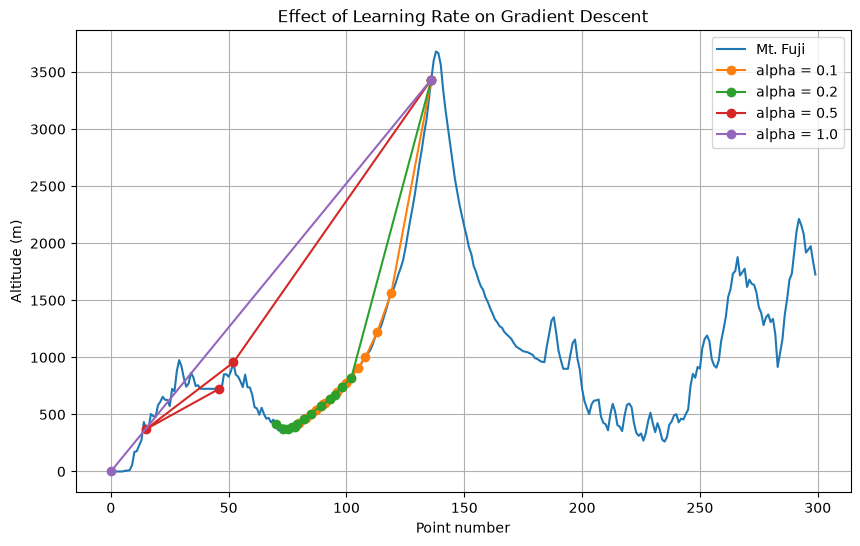

In [5]:
# Problem 8: Compare different learning rates

start_point = 136
alpha_values = [0.1, 0.2, 0.5, 1.0]

plt.figure(figsize=(10, 6))

plt.plot(
    fuji[:, 0],
    fuji[:, 3],
    label="Mt. Fuji"
)

for alpha in alpha_values:

    path = descend_mountain(
        fuji,
        start_point=start_point,
        alpha=alpha
    )

    altitudes = fuji[path, 3]

    plt.plot(
        path,
        altitudes,
        marker="o",
        label=f"alpha = {alpha}"
    )

plt.xlabel("Point number")
plt.ylabel("Altitude (m)")
plt.title("Effect of Learning Rate on Gradient Descent")
plt.legend()
plt.grid()

plt.show()

In [6]:
for alpha in alpha_values:

    path = descend_mountain(
        fuji,
        start_point=136,
        alpha=alpha
    )

    final_point = path[-1]
    final_altitude = fuji[final_point, 3]

    print(
        f"alpha = {alpha}: "
        f"steps = {len(path)}, "
        f"final point = {final_point}, "
        f"final altitude = {final_altitude:.2f} m"
    )

alpha = 0.1: steps = 18, final point = 80, final altitude = 420.60 m
alpha = 0.2: steps = 14, final point = 75, final altitude = 371.19 m
alpha = 0.5: steps = 4, final point = 46, final altitude = 724.50 m
alpha = 1.0: steps = 2, final point = 0, final altitude = 0.00 m
